# Workshop 2 – Big Data Process Report
## Amazon Sales Dataset – E-Commerce Revenue Prediction



## Step 1 – Data Exploration, Transformation & Model Trainin

### 1.1 – Library Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

### 1.2 – Load & Initial Overview

In [5]:
df = pd.read_csv('/content/drive/MyDrive/Big_Data/amazon_sales_dataset.csv')
df['order_date'] = pd.to_datetime(df['order_date'])
print('=== DATASET SHAPE ===')
print(f'Rows: {df.shape[0]:,}   Columns: {df.shape[1]}')
print(f'Date Range: {df["order_date"].min().date()} to {df["order_date"].max().date()}')
print()
df.head()

=== DATASET SHAPE ===
Rows: 50,000   Columns: 13
Date Range: 2022-01-01 to 2023-12-31



,order_id,order_date,product_id,product_category,price,discount_percent,quantity_sold,customer_region,payment_method,rating,review_count,discounted_price,total_revenue
0,1,2022-04-13,2637,Books,128.75,10,4,North America,UPI,3.5,443,115.88,463.52
1,2,2023-03-12,2300,Fashion,302.60,20,5,Asia,Credit Card,3.7,475,242.08,1210.40
2,3,2022-09-28,3670,Sports,495.80,20,2,Europe,UPI,4.4,183,396.64,793.28
3,4,2022-04-17,2522,Books,371.95,15,4,Middle East,UPI,5.0,212,316.16,1264.64
4,5,2022-03-13,1717,Beauty,201.68,0,4,Middle East,UPI,4.6,308,201.68,806.72


In [6]:
print('=== DATA TYPES ===')
print(df.dtypes)
print()
print('=== MISSING VALUES ===')
print(df.isnull().sum())

=== DATA TYPES ===
order_id                     int64
order_date          datetime64[ns]
product_id                   int64
product_category            object
price                      float64
discount_percent             int64
quantity_sold                int64
customer_region             object
payment_method              object
rating                     float64
review_count                 int64
discounted_price           float64
total_revenue              float64
dtype: object

=== MISSING VALUES ===
order_id            0
order_date          0
product_id          0
product_category    0
price               0
discount_percent    0
quantity_sold       0
customer_region     0
payment_method      0
rating              0
review_count        0
discounted_price    0
total_revenue       0
dtype: int64


In [7]:
print('=== DESCRIPTIVE STATISTICS ===')
df.describe().round(2)

=== DESCRIPTIVE STATISTICS ===


,order_id,order_date,product_id,price,discount_percent,quantity_sold,rating,review_count,discounted_price,total_revenue
count,50000.00,50000,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00,50000.00
mean,25000.50,2022-12-31 10:47:16.800000256,2986.85,252.51,13.34,3.00,3.00,249.33,218.89,657.33
min,1.00,2022-01-01 00:00:00,1000.00,5.01,0.00,1.00,1.00,0.00,3.53,3.84
25%,12500.75,2022-07-02 00:00:00,1983.00,127.84,5.00,2.00,2.00,125.00,109.68,240.32
50%,25000.50,2023-01-02 00:00:00,2983.00,252.97,10.00,3.00,3.00,250.00,215.80,505.41
75%,37500.25,2023-07-02 00:00:00,3989.00,376.34,20.00,4.00,4.00,374.00,322.70,968.97
max,50000.00,2023-12-31 00:00:00,4999.00,499.99,30.00,5.00,5.00,499.00,499.91,2499.55
std,14433.90,NaN,1156.37,143.03,9.85,1.42,1.15,144.25,127.32,526.22


In [8]:
print('=== CATEGORY COUNTS ===')
print('Product Categories:', df['product_category'].unique().tolist())
print('Customer Regions  :', df['customer_region'].unique().tolist())
print('Payment Methods   :', df['payment_method'].unique().tolist())
print()
print(f'Total Revenue : ${df["total_revenue"].sum():,.2f}')
print(f'Avg Order Val : ${df["total_revenue"].mean():.2f}')
print(f'Avg Rating    : {df["rating"].mean():.4f}')

=== CATEGORY COUNTS ===
Product Categories: ['Books', 'Fashion', 'Sports', 'Beauty', 'Electronics', 'Home & Kitchen']
Customer Regions  : ['North America', 'Asia', 'Europe', 'Middle East']
Payment Methods   : ['UPI', 'Credit Card', 'Wallet', 'Cash on Delivery', 'Debit Card']

Total Revenue : $32,866,573.74
Avg Order Val : $657.33
Avg Rating    : 2.9963


In [9]:
df['year']    = df['order_date'].dt.year
df['month']   = df['order_date'].dt.month
df['quarter'] = df['order_date'].dt.quarter
df['month_name'] = df['order_date'].dt.strftime('%b')

print('Temporal features added: year, month, quarter, month_name')
df[['order_date','year','month','quarter','month_name']].head()

Temporal features added: year, month, quarter, month_name


,order_date,year,month,quarter,month_name
0,2022-04-13,2022,4,2,Apr
1,2023-03-12,2023,3,1,Mar
2,2022-09-28,2022,9,3,Sep
3,2022-04-17,2022,4,2,Apr
4,2022-03-13,2022,3,1,Mar


### 1.4 – Exploratory Data Analysis (EDA)

#### Fig 1 – Revenue & Units Sold by Product Category

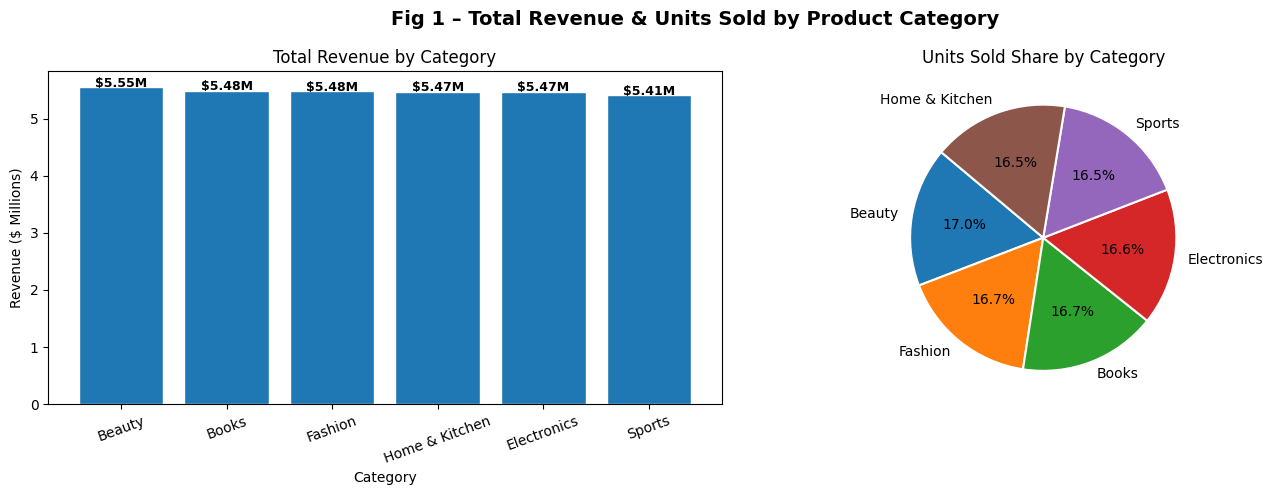


Revenue by Category:
product_category
Beauty            $5,550,625
Books             $5,484,863
Fashion           $5,480,123
Home & Kitchen    $5,473,133
Electronics       $5,470,594
Sports            $5,407,236
Name: total_revenue, dtype: object


In [11]:
cat_rev = df.groupby('product_category')['total_revenue'].sum().sort_values(ascending=False)
cat_qty = df.groupby('product_category')['quantity_sold'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Fig 1 – Total Revenue & Units Sold by Product Category',
             fontsize=14, fontweight='bold')

bars = axes[0].bar(cat_rev.index, cat_rev.values / 1e6, edgecolor='white')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Revenue ($ Millions)')
axes[0].set_title('Total Revenue by Category')
axes[0].tick_params(axis='x', rotation=20)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.01,
                 f'${bar.get_height():.2f}M',
                 ha='center', fontsize=9, fontweight='bold')

axes[1].pie(cat_qty.values, labels=cat_qty.index, autopct='%1.1f%%', startangle=140,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Units Sold Share by Category')

plt.tight_layout()
plt.savefig('fig1_category_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nRevenue by Category:')
print(cat_rev.apply(lambda x: f'${x:,.0f}'))

#### Fig 2 – Monthly Revenue Trends & Quarterly Breakdown

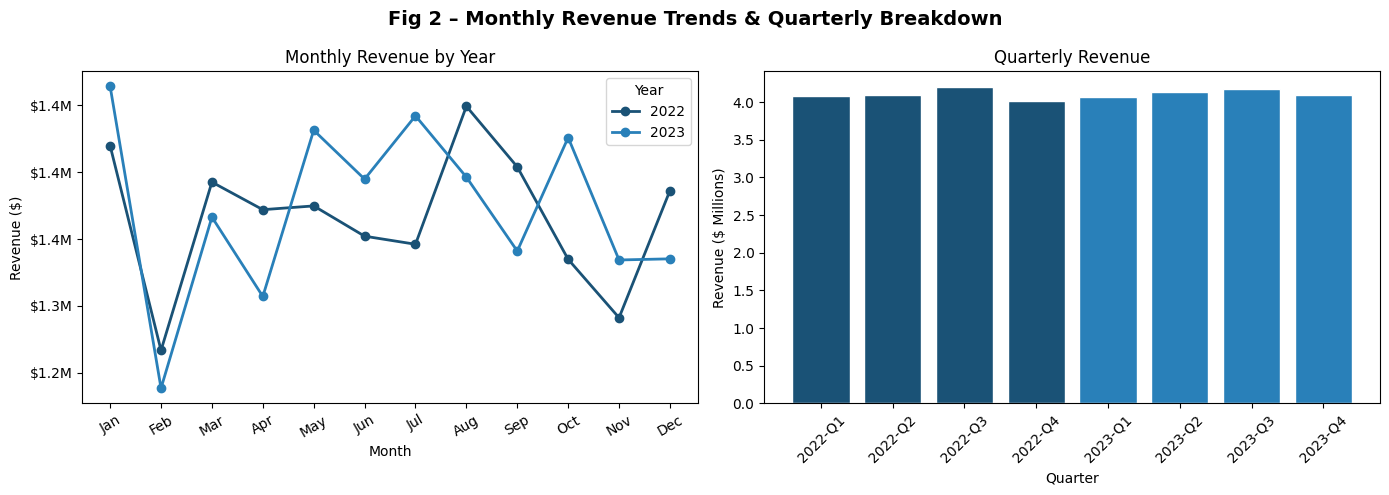


Quarterly Revenue:
  label  total_revenue
2022-Q1     4079051.60
2022-Q2     4098860.89
2022-Q3     4199364.30
2022-Q4     4012127.77
2023-Q1     4068973.91
2023-Q2     4133238.84
2023-Q3     4179506.40
2023-Q4     4095450.03


In [12]:
monthly = df.groupby(['year', 'month'])['total_revenue'].sum().reset_index()
pivot   = monthly.pivot(index='month', columns='year', values='total_revenue').fillna(0)
q_rev   = df.groupby(['year', 'quarter'])['total_revenue'].sum().reset_index()
q_rev['label'] = q_rev['year'].astype(str) + '-Q' + q_rev['quarter'].astype(str)

month_labels = ['Jan','Feb','Mar','Apr','May','Jun',
                'Jul','Aug','Sep','Oct','Nov','Dec']
yr_colors = ['#1A5276', '#2980B9']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Fig 2 – Monthly Revenue Trends & Quarterly Breakdown',
             fontsize=14, fontweight='bold')

for idx, yr in enumerate(sorted(pivot.columns)):
    vals = [pivot.loc[m, yr] if m in pivot.index else 0 for m in range(1, 13)]
    axes[0].plot(month_labels, vals, marker='o', linewidth=2,
                 label=str(int(yr)), color=yr_colors[idx])
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Revenue ($)')
axes[0].set_title('Monthly Revenue by Year')
axes[0].yaxis.set_major_formatter(
    mticker.FuncFormatter(lambda x, _: f'${x/1e6:.1f}M'))
axes[0].legend(title='Year')
axes[0].tick_params(axis='x', rotation=30)

q_colors = [yr_colors[0] if y == 2022 else yr_colors[1] for y in q_rev['year']]
axes[1].bar(q_rev['label'], q_rev['total_revenue'] / 1e6,
            color=q_colors, edgecolor='white')
axes[1].set_xlabel('Quarter')
axes[1].set_ylabel('Revenue ($ Millions)')
axes[1].set_title('Quarterly Revenue')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('fig2_monthly_trends.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nQuarterly Revenue:')
print(q_rev[['label','total_revenue']].to_string(index=False))

#### Fig 3 – Regional Revenue & Order Count

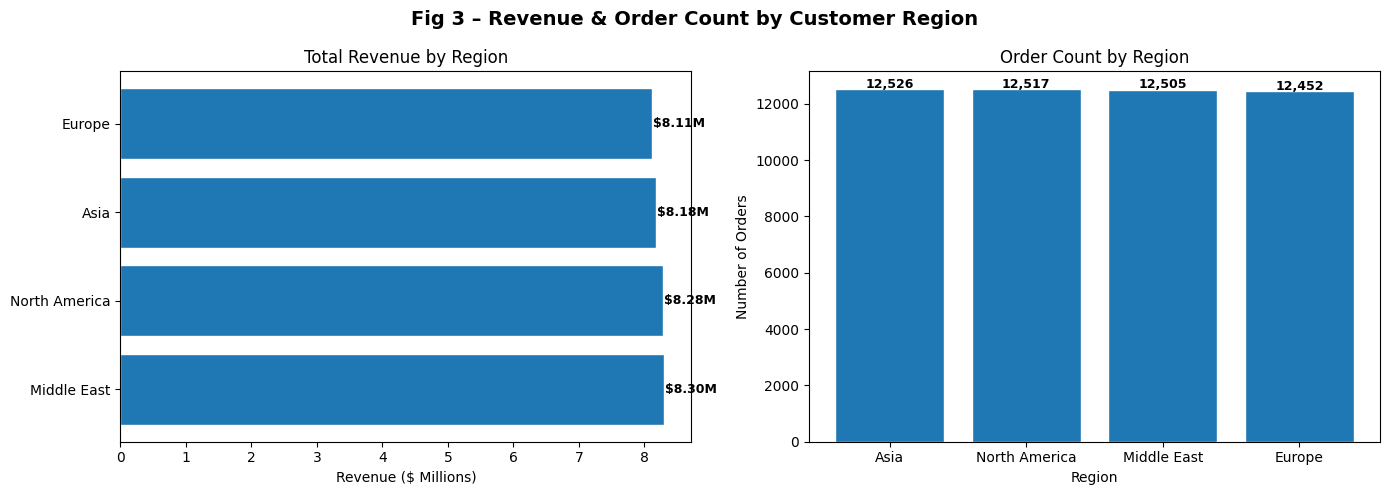


Revenue by Region:
customer_region
Middle East      $8,301,844
North America    $8,277,218
Asia             $8,175,200
Europe           $8,112,312
Name: total_revenue, dtype: object


In [14]:
reg_rev    = df.groupby('customer_region')['total_revenue'].sum().sort_values(ascending=False)
reg_orders = df.groupby('customer_region').size().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Fig 3 – Revenue & Order Count by Customer Region',
             fontsize=14, fontweight='bold')

bars = axes[0].barh(reg_rev.index, reg_rev.values / 1e6, edgecolor='white')
axes[0].set_xlabel('Revenue ($ Millions)')
axes[0].set_title('Total Revenue by Region')
for bar in bars:
    axes[0].text(bar.get_width() + 0.02,
                 bar.get_y() + bar.get_height()/2,
                 f'${bar.get_width():.2f}M',
                 va='center', fontsize=9, fontweight='bold')

axes[1].bar(reg_orders.index, reg_orders.values, edgecolor='white')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Number of Orders')
axes[1].set_title('Order Count by Region')
for i, v in enumerate(reg_orders.values):
    axes[1].text(i, v + 50, f'{v:,}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('fig3_regional.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nRevenue by Region:')
print(reg_rev.apply(lambda x: f'${x:,.0f}'))

#### Fig 4 – Impact of Discount on Revenue & Rating

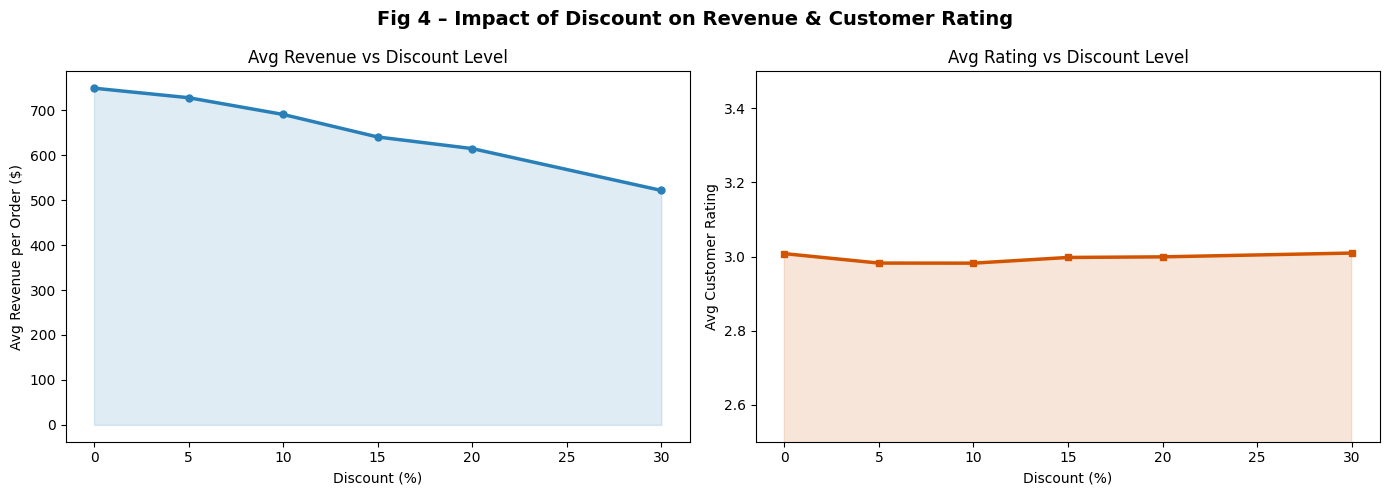

Revenue range by discount: $521.56 – $749.03
Rating range by discount: 2.982 – 3.009


In [15]:
disc_rev  = df.groupby('discount_percent')['total_revenue'].mean()
disc_rate = df.groupby('discount_percent')['rating'].mean()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Fig 4 – Impact of Discount on Revenue & Customer Rating',
             fontsize=14, fontweight='bold')

axes[0].plot(disc_rev.index, disc_rev.values,
             color='#2980B9', linewidth=2.5, marker='o', markersize=5)
axes[0].fill_between(disc_rev.index, disc_rev.values, alpha=0.15, color='#2980B9')
axes[0].set_xlabel('Discount (%)')
axes[0].set_ylabel('Avg Revenue per Order ($)')
axes[0].set_title('Avg Revenue vs Discount Level')

axes[1].plot(disc_rate.index, disc_rate.values,
             color='#D35400', linewidth=2.5, marker='s', markersize=5)
axes[1].fill_between(disc_rate.index, disc_rate.values, alpha=0.15, color='#D35400')
axes[1].set_xlabel('Discount (%)')
axes[1].set_ylabel('Avg Customer Rating')
axes[1].set_title('Avg Rating vs Discount Level')
axes[1].set_ylim(2.5, 3.5)

plt.tight_layout()
plt.savefig('fig4_discount_impact.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Revenue range by discount: ${disc_rev.min():.2f} – ${disc_rev.max():.2f}')
print(f'Rating range by discount: {disc_rate.min():.3f} – {disc_rate.max():.3f}')

#### Fig 5 – Payment Method Preference & Revenue Share

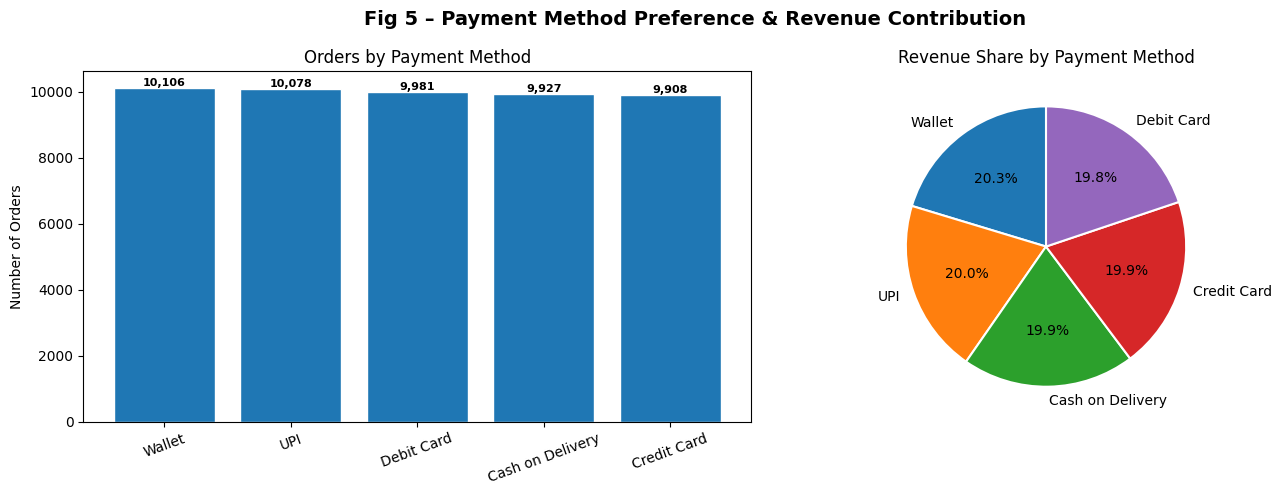


Orders by Payment Method:
payment_method
Wallet              10106
UPI                 10078
Debit Card           9981
Cash on Delivery     9927
Credit Card          9908
dtype: int64


In [17]:
pay_orders = df.groupby('payment_method').size().sort_values(ascending=False)
pay_rev    = df.groupby('payment_method')['total_revenue'].sum().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Fig 5 – Payment Method Preference & Revenue Contribution',
             fontsize=14, fontweight='bold')

axes[0].bar(pay_orders.index, pay_orders.values, edgecolor='white')
axes[0].set_ylabel('Number of Orders')
axes[0].set_title('Orders by Payment Method')
axes[0].tick_params(axis='x', rotation=20)
for i, v in enumerate(pay_orders.values):
    axes[0].text(i, v + 50, f'{v:,}', ha='center', fontsize=8, fontweight='bold')

axes[1].pie(pay_rev.values, labels=pay_rev.index, autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})
axes[1].set_title('Revenue Share by Payment Method')

plt.tight_layout()
plt.savefig('fig5_payment.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nOrders by Payment Method:')
print(pay_orders)

#### Fig 6 – Rating Distribution & Category × Region Revenue Heatmap

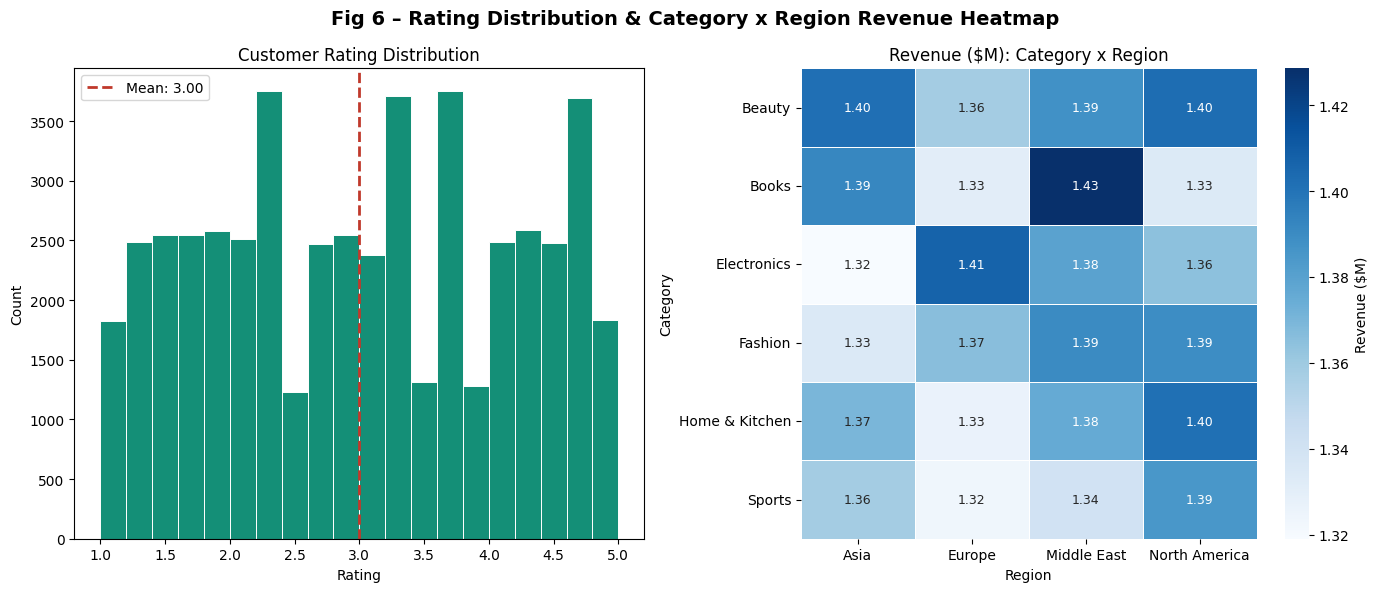

Rating Stats: Mean=2.9963, Std=1.1543
Min=1.0, Max=5.0


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Fig 6 – Rating Distribution & Category x Region Revenue Heatmap',
             fontsize=14, fontweight='bold')

axes[0].hist(df['rating'], bins=20, color='#148F77', edgecolor='white', linewidth=0.7)
axes[0].axvline(df['rating'].mean(), color='#C0392B', linestyle='--', linewidth=2,
                label=f'Mean: {df["rating"].mean():.2f}')
axes[0].set_xlabel('Rating')
axes[0].set_ylabel('Count')
axes[0].set_title('Customer Rating Distribution')
axes[0].legend()

heatmap_data = df.pivot_table(
    index='product_category', columns='customer_region',
    values='total_revenue', aggfunc='sum') / 1e6
sns.heatmap(heatmap_data, annot=True, fmt='.2f', cmap='Blues',
            ax=axes[1], linewidths=0.5,
            annot_kws={'size': 9},
            cbar_kws={'label': 'Revenue ($M)'})
axes[1].set_title('Revenue ($M): Category x Region')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Category')

plt.tight_layout()
plt.savefig('fig6_rating_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Rating Stats: Mean={df["rating"].mean():.4f}, Std={df["rating"].std():.4f}')
print(f'Min={df["rating"].min()}, Max={df["rating"].max()}')

#### Fig 7 – Pearson Correlation Matrix

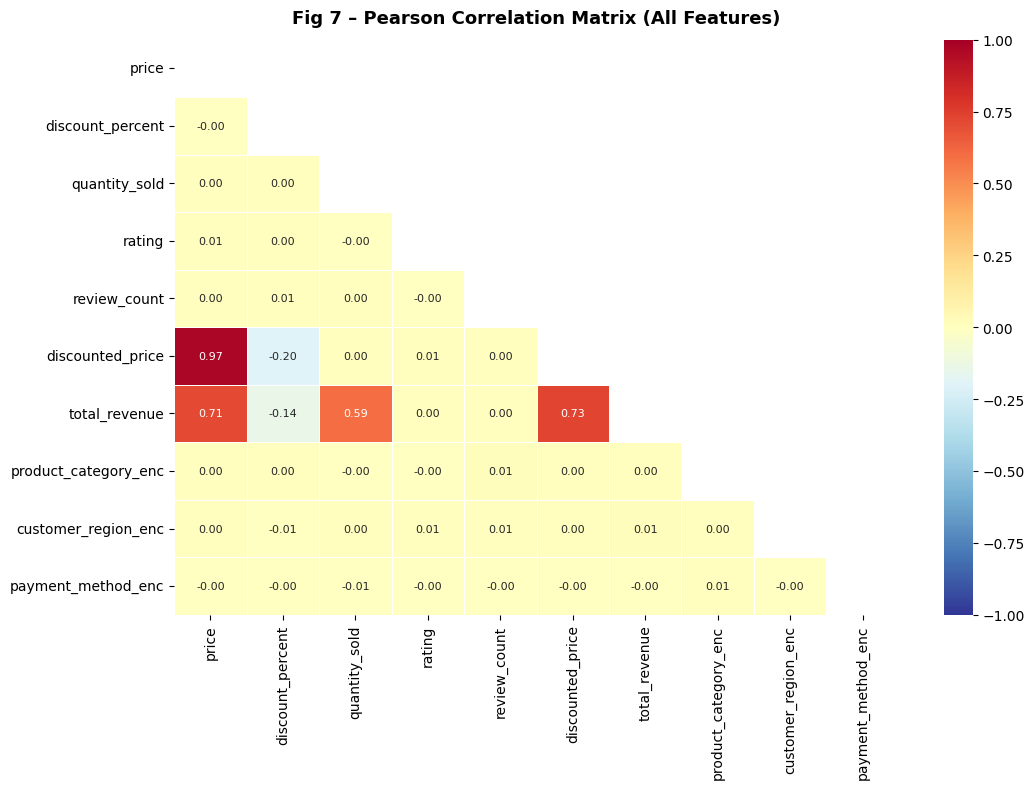

Top correlations with total_revenue:
total_revenue           1.000000
discounted_price        0.729694
price                   0.711094
quantity_sold           0.594404
customer_region_enc     0.008128
review_count            0.002208
rating                  0.001804
product_category_enc    0.000236
payment_method_enc     -0.001161
discount_percent       -0.144392
Name: total_revenue, dtype: float64


In [19]:
le = LabelEncoder()
df_enc = df.copy()
for col in ['product_category', 'customer_region', 'payment_method']:
    df_enc[col + '_enc'] = le.fit_transform(df_enc[col])

num_cols = ['price', 'discount_percent', 'quantity_sold', 'rating',
            'review_count', 'discounted_price', 'total_revenue',
            'product_category_enc', 'customer_region_enc', 'payment_method_enc']
corr = df_enc[num_cols].corr()

fig, ax = plt.subplots(figsize=(11, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlBu_r',
            ax=ax, mask=mask, linewidths=0.5,
            annot_kws={'size': 8}, vmin=-1, vmax=1)
ax.set_title('Fig 7 – Pearson Correlation Matrix (All Features)',
             fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('fig7_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top correlations with total_revenue:')
print(corr['total_revenue'].sort_values(ascending=False))

#### Fig 8 – Avg Revenue & Avg Rating by Category and Payment Method

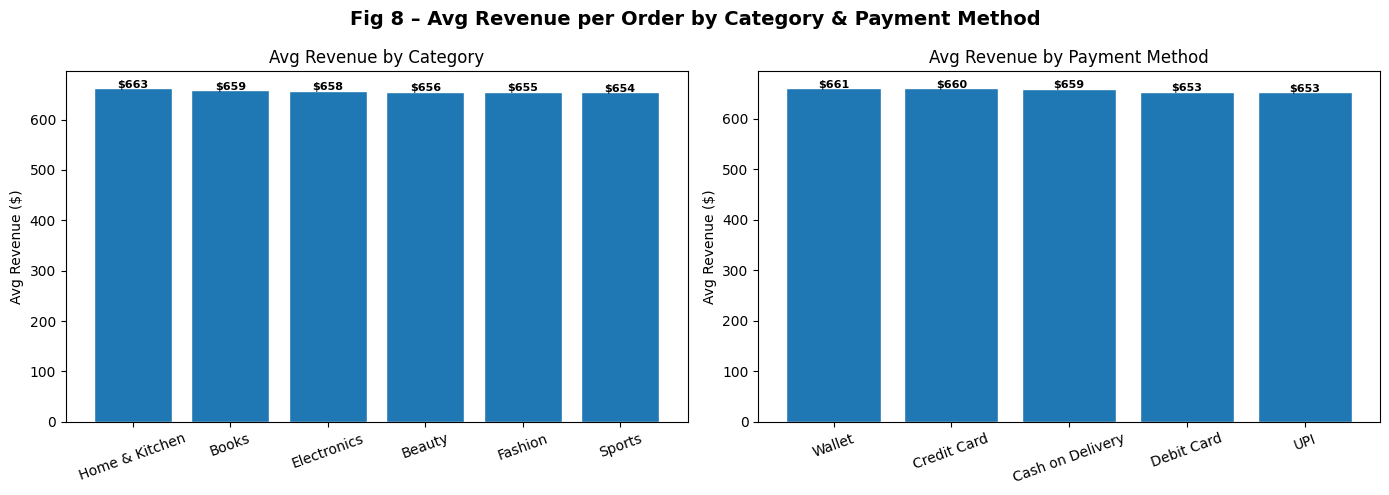

Avg Revenue by Category:
product_category    avg_rev
  Home & Kitchen 662.767323
           Books 658.684164
     Electronics 657.523321
          Beauty 655.714704
         Fashion 655.125325
          Sports 654.233009

Avg Revenue by Payment:
  payment_method    avg_rev
          Wallet 660.858744
     Credit Card 660.081465
Cash on Delivery 659.452699
      Debit Card 653.443516
             UPI 652.851899


In [21]:
cat_avg = df.groupby('product_category').agg(
    avg_rev=('total_revenue', 'mean'),
    avg_rating=('rating', 'mean')
).reset_index().sort_values('avg_rev', ascending=False)

pay_avg = df.groupby('payment_method').agg(
    avg_rev=('total_revenue', 'mean'),
    avg_rating=('rating', 'mean')
).reset_index().sort_values('avg_rev', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Fig 8 – Avg Revenue per Order by Category & Payment Method',
             fontsize=14, fontweight='bold')

bars = axes[0].bar(cat_avg['product_category'], cat_avg['avg_rev'], edgecolor='white')
axes[0].set_ylabel('Avg Revenue ($)')
axes[0].set_title('Avg Revenue by Category')
axes[0].tick_params(axis='x', rotation=20)
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f'${bar.get_height():.0f}',
                 ha='center', fontsize=8, fontweight='bold')

bars2 = axes[1].bar(pay_avg['payment_method'], pay_avg['avg_rev'], edgecolor='white')
axes[1].set_ylabel('Avg Revenue ($)')
axes[1].set_title('Avg Revenue by Payment Method')
axes[1].tick_params(axis='x', rotation=20)
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 1,
                 f'${bar.get_height():.0f}',
                 ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('fig8_avg_revenue.png', dpi=150, bbox_inches='tight')
plt.show()

print('Avg Revenue by Category:')
print(cat_avg[['product_category','avg_rev']].to_string(index=False))
print('\nAvg Revenue by Payment:')
print(pay_avg[['payment_method','avg_rev']].to_string(index=False))

### 1.5 – Data Preprocessing for Modelling

In [22]:
# Label encode categorical columns
le = LabelEncoder()
df_model = df.copy()
for col in ['product_category', 'customer_region', 'payment_method']:
    df_model[col + '_enc'] = le.fit_transform(df_model[col])

feature_cols = ['price', 'discount_percent', 'quantity_sold', 'rating',
                'review_count', 'month', 'quarter',
                'product_category_enc', 'customer_region_enc', 'payment_method_enc']
target = 'total_revenue'

X = df_model[feature_cols]
y = df_model[target]

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Standardise
scaler   = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print('Feature Columns:', feature_cols)
print(f'\nTrain: {X_train.shape[0]:,} rows | Test: {X_test.shape[0]:,} rows')
print(f'Target range: ${y.min():.2f} – ${y.max():.2f}  |  Mean: ${y.mean():.2f}')

Feature Columns: ['price', 'discount_percent', 'quantity_sold', 'rating', 'review_count', 'month', 'quarter', 'product_category_enc', 'customer_region_enc', 'payment_method_enc']

Train: 40,000 rows | Test: 10,000 rows
Target range: $3.84 – $2499.55  |  Mean: $657.33


### 1.6 – Model Training: Revenue Prediction (Regression)

In [23]:
models = {
    'Linear Regression'  : LinearRegression(),
    'Random Forest'      : RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting'  : GradientBoostingRegressor(n_estimators=100, random_state=42)
}

results = {}
print(f'{"Model":<25} {"MAE":>10} {"RMSE":>10} {"R2":>10}')
print('-' * 60)
for name, model in models.items():
    model.fit(X_train_s, y_train)
    preds = model.predict(X_test_s)
    mae  = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2   = r2_score(y_test, preds)
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'preds': preds}
    print(f'{name:<25} {mae:>10.3f} {rmse:>10.3f} {r2:>10.6f}')

best = max(results, key=lambda k: results[k]['R2'])
print(f'\nBest Model: {best}  (R2 = {results[best]["R2"]:.6f})')

Model                            MAE       RMSE         R2
------------------------------------------------------------
Linear Regression            139.403    187.214   0.870735
Random Forest                  0.655      1.014   0.999996
Gradient Boosting             14.028     18.125   0.998788

Best Model: Random Forest  (R2 = 0.999996)


#### Fig 9 – Model Performance Comparison (MAE, RMSE, R²)

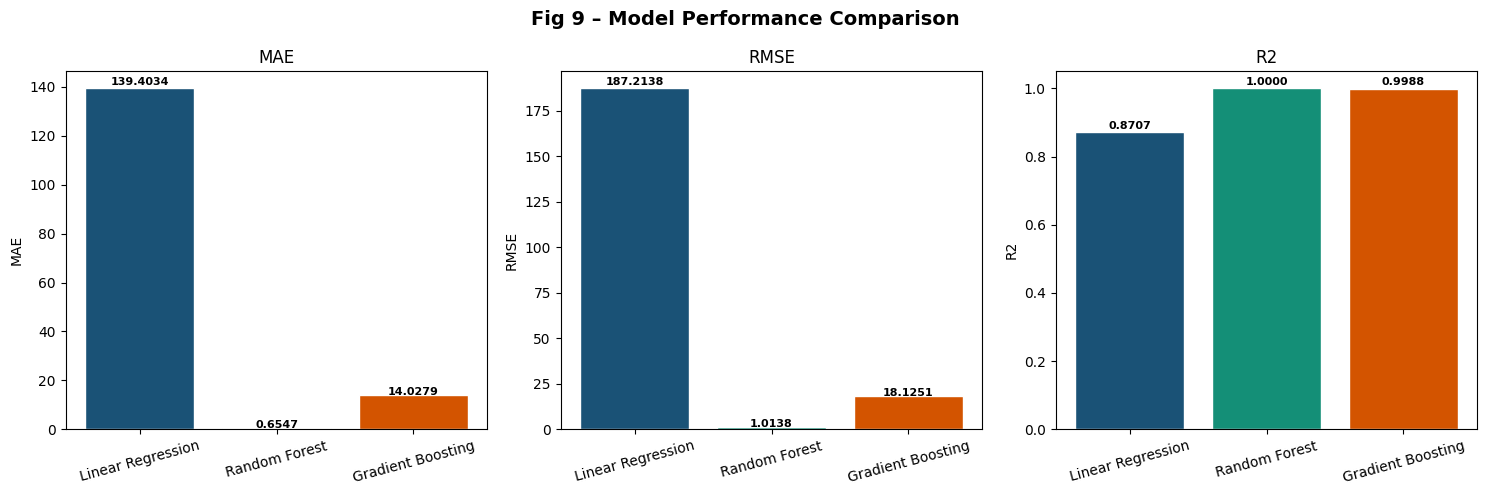

In [24]:
metrics     = ['MAE', 'RMSE', 'R2']
bar_colors  = ['#1A5276', '#148F77', '#D35400']
model_names = list(results.keys())

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Fig 9 – Model Performance Comparison',
             fontsize=14, fontweight='bold')

for i, metric in enumerate(metrics):
    vals = [results[m][metric] for m in model_names]
    bars = axes[i].bar(model_names, vals, color=bar_colors, edgecolor='white')
    axes[i].set_title(metric)
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=15)
    for bar, v in zip(bars, vals):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() * 1.01,
                     f'{v:.4f}', ha='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig('fig9_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

#### Fig 10 – Actual vs Predicted Revenue & Feature Importance

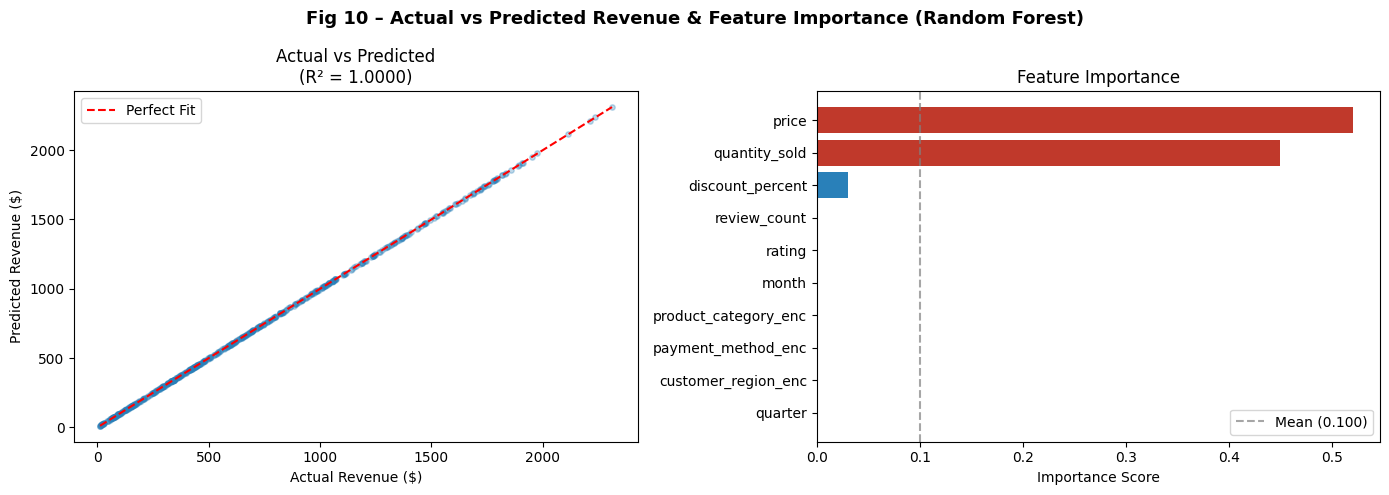

Feature Importances (descending):
price                   0.5201
quantity_sold           0.4493
discount_percent        0.0306
review_count            0.0000
rating                  0.0000
month                   0.0000
product_category_enc    0.0000
payment_method_enc      0.0000
customer_region_enc     0.0000
quarter                 0.0000
dtype: float64


In [25]:
rf_model   = models['Random Forest']
best_preds = results['Random Forest']['preds']

# Random sample for scatter
idx      = np.random.choice(len(y_test), 500, replace=False)
y_sample = y_test.values[idx]
p_sample = best_preds[idx]

feat_imp = pd.Series(
    rf_model.feature_importances_, index=feature_cols
).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Fig 10 – Actual vs Predicted Revenue & Feature Importance (Random Forest)',
             fontsize=13, fontweight='bold')

axes[0].scatter(y_sample, p_sample, alpha=0.3, color='#2980B9', s=15)
mn, mx = min(y_sample.min(), p_sample.min()), max(y_sample.max(), p_sample.max())
axes[0].plot([mn, mx], [mn, mx], 'r--', linewidth=1.5, label='Perfect Fit')
axes[0].set_xlabel('Actual Revenue ($)')
axes[0].set_ylabel('Predicted Revenue ($)')
axes[0].set_title(f'Actual vs Predicted\n(R² = {results["Random Forest"]["R2"]:.4f})')
axes[0].legend()

colors_fi = ['#C0392B' if v > feat_imp.mean() else '#2980B9' for v in feat_imp.values]
axes[1].barh(feat_imp.index, feat_imp.values, color=colors_fi)
axes[1].axvline(feat_imp.mean(), color='grey', linestyle='--', alpha=0.7,
                label=f'Mean ({feat_imp.mean():.3f})')
axes[1].set_xlabel('Importance Score')
axes[1].set_title('Feature Importance')
axes[1].legend()

plt.tight_layout()
plt.savefig('fig10_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

print('Feature Importances (descending):')
print(feat_imp.sort_values(ascending=False).round(4))

## Step 2 – Insight Generation

In [26]:
print('=' * 60)
print('KEY BUSINESS INSIGHTS – Amazon Sales Dataset')
print('=' * 60)

print('\n1. REVENUE DISTRIBUTION')
print(f'   Total Revenue       : ${df["total_revenue"].sum():>12,.2f}')
print(f'   Avg Order Value     : ${df["total_revenue"].mean():>12.2f}')
print(f'   Top Category        : {cat_rev.idxmax()} (${cat_rev.max():,.0f})')
print(f'   Bottom Category     : {cat_rev.idxmin()} (${cat_rev.min():,.0f})')
print(f'   Top Region          : {reg_rev.idxmax()} (${reg_rev.max():,.0f})')

print('\n2. DISCOUNT ANALYSIS')
no_disc   = df[df['discount_percent'] == 0]['total_revenue'].mean()
high_disc = df[df['discount_percent'] >= 30]['total_revenue'].mean()
print(f'   Avg Rev (0% disc)   : ${no_disc:.2f}')
print(f'   Avg Rev (>=30% disc): ${high_disc:.2f}')
print(f'   Revenue drop        : {(1 - high_disc/no_disc)*100:.1f}%')

print('\n3. RATING ANALYSIS')
print(f'   Avg Rating          : {df["rating"].mean():.4f}')
print(f'   High rated (>=4) %  : {(df["rating"] >= 4).mean()*100:.1f}%')
print(f'   Low rated (<2.5) %  : {(df["rating"] < 2.5).mean()*100:.1f}%')

print('\n4. HIGH-VALUE ORDERS (top 10% revenue)')
top10 = df[df['total_revenue'] >= df['total_revenue'].quantile(0.9)]
print(f'   Count               : {len(top10):,}')
print(f'   Avg Revenue         : ${top10["total_revenue"].mean():.2f}')
print(f'   Top Category        : {top10["product_category"].value_counts().idxmax()}')
print(f'   Top Region          : {top10["customer_region"].value_counts().idxmax()}')

print('\n5. MODEL PREDICTION SUMMARY')
for name, res in results.items():
    print(f'   {name:<25} R2={res["R2"]:.4f}  RMSE=${res["RMSE"]:.2f}')

KEY BUSINESS INSIGHTS – Amazon Sales Dataset

1. REVENUE DISTRIBUTION
   Total Revenue       : $32,866,573.74
   Avg Order Value     : $      657.33
   Top Category        : Beauty ($5,550,625)
   Bottom Category     : Sports ($5,407,236)
   Top Region          : Middle East ($8,301,844)

2. DISCOUNT ANALYSIS
   Avg Rev (0% disc)   : $749.03
   Avg Rev (>=30% disc): $521.56
   Revenue drop        : 30.4%

3. RATING ANALYSIS
   Avg Rating          : 2.9963
   High rated (>=4) %  : 26.1%
   Low rated (<2.5) %  : 36.5%

4. HIGH-VALUE ORDERS (top 10% revenue)
   Count               : 5,001
   Avg Revenue         : $1779.09
   Top Category        : Home & Kitchen
   Top Region          : North America

5. MODEL PREDICTION SUMMARY
   Linear Regression         R2=0.8707  RMSE=$187.21
   Random Forest             R2=1.0000  RMSE=$1.01
   Gradient Boosting         R2=0.9988  RMSE=$18.13
